## Transient 1

Define the model for the transient event

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import emcee
import corner
import astropy.visualization.hist
from IPython.display import display, Math

def model(x, time):

    b, t0, A, alpha = x
    y = np.where(time < t0,
                 b,
                 b + A * np.exp(-alpha * (time - t0)))
    return y

Define the loglikelihood, logprior and posterior.

Assuming a gaussian noise, the likelihood is $$ p(y_i|t_i, M(b, t_0, A, \alpha), \sigma) = N(y_i - M(x_i,b, t_0, A, \alpha)|\sigma) = \frac{1}{\sqrt{2 \pi \sigma^2}} \exp \left( - \frac{(y_i - M(b, t_0, A, \alpha,x_i))^2}{2 \sigma^2} \right). $$

Given that the piors are uniform, the prior is just
$$ p(b, t_0, A, \alpha) = C\ \text{within the limits and 0 otherwise}$$

In [37]:
def logLikelihood(x,time,flux,uncertainties):
    return np.sum(norm(loc = model(x,time), scale = uncertainties).logpdf(flux))

def logPrior(x):
    b, t0, A, alpha = x
    if 0 <= b <= 50 and 0 <= A <= 50 and 0 <= t0 <= 100 and np.exp(-5) <= alpha <= np.exp(5):
        return -np.log(alpha)  # log(1/alpha) indeed p(alpha)=1/alpha so when you make the log prior you get -log(alpha)
    else:
        return -np.inf

def logPosterior(x,time,flux,uncertainties):
    
    lp =  logPrior(x)
    if not np.isfinite(lp):
        return -np.inf
    else:
        return logLikelihood(x,time,flux,uncertainties) + lp

Load the data and plot them and define the starting guess for the parameters by visual inspection

Starting guess for b is 10.0
Starting guess for t0 is 50.0
Starting guess for A is 5.0
Starting guess for alpha is 0.12


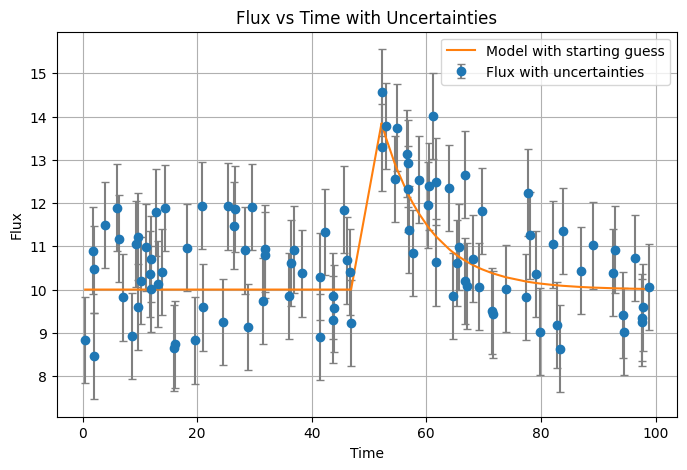

In [38]:
labels = ["b","t0","A","alpha"]

# Load the data
data = np.load('transient.npy')
time = data[:, 0]
flux = data[:, 1]
uncertainties = data[:, 2]

# Create the errorbar plot with the model and initial guess
plt.figure(figsize=(8, 5))
plt.errorbar(time, flux, yerr=uncertainties, fmt='o', 
             ecolor='gray', capsize=3, label='Flux with uncertainties')
plt.xlabel('Time')
plt.ylabel('Flux')
plt.title('Flux vs Time with Uncertainties')

starting_guesses = np.array([10,50,5,0.12])
plt.plot(time,model(starting_guesses,time),label='Model with starting guess')
plt.legend()
plt.grid(True)

print("\n".join([f"Starting guess for {label} is {value}" for label, value in zip(labels, starting_guesses)]))

Initialize and run the sampler

In [39]:
ndim = 4  # number of parameters in the model
nwalkers = 24  # number of MCMC walkers
nsteps = 20000  # number of MCMC steps to take **for each walker**

np.random.seed(0)
starting_guesses = starting_guesses+1e-2*np.random.randn(nwalkers, ndim)
sampler = emcee.EnsembleSampler(nwalkers, ndim, logPosterior,args=[time,flux,uncertainties])
sampler.run_mcmc(starting_guesses, nsteps)
emcee_trace = sampler.get_chain()

Check if some walker gets stuck by visual inspection and computing the std and average. If a walker has a standard deviation much smaller than the others, it may be stuck. If a walker's mean/median is far from the others, it may be stuck.

C:\Users\edoardo ferocino\AppData\Local\Temp\ipykernel_10076\2005742602.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Parameter b:
  Walker 1: std = 0.1268, mean = 10.2944
  Walker 2: std = 0.1206, mean = 10.2976
  Walker 3: std = 0.1245, mean = 10.3010
  Walker 4: std = 0.1169, mean = 10.3023
  Walker 5: std = 0.1223, mean = 10.2922
  Walker 6: std = 0.1197, mean = 10.2927
  Walker 7: std = 0.1272, mean = 10.2994
  Walker 8: std = 0.1233, mean = 10.3114
  Walker 9: std = 0.1240, mean = 10.2946
  Walker 10: std = 0.1215, mean = 10.2993
  Walker 11: std = 0.1250, mean = 10.2966
  Walker 12: std = 0.1261, mean = 10.2966
  Walker 13: std = 0.1267, mean = 10.2995
  Walker 14: std = 0.1226, mean = 10.2987
  Walker 15: std = 0.1200, mean = 10.3047
  Walker 16: std = 0.1249, mean = 10.3103
  Walker 17: std = 0.1226, mean = 10.2958
  Walker 18: std = 0.1192, mean = 10.2950
  Walker 19: std = 0.1239, mean = 10.3006
  Walker 20: std = 0.1206, mean = 10.2988
  Walker 21: std = 0.1249, mean = 10.2927
  Walker 22: std = 0.1231, mean = 10.2872
  Walker 23: std = 0.1200, mean = 10.2977
  Walker 24: std = 0.1214, mea

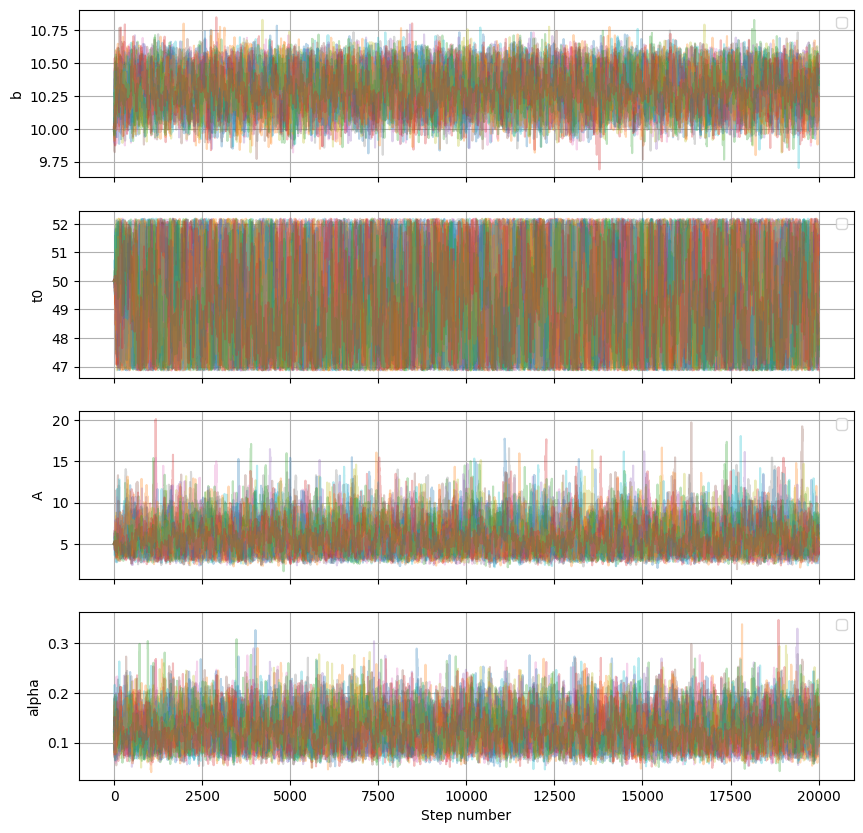

In [40]:
# check the walkers if someone gets stuck
fig, axes = plt.subplots(ndim, 1, figsize=(10, 2.5*ndim), sharex=True)

for i in range(ndim):
    ax = axes[i]
    #for w in walker_indices:
    #    ax.plot(emcee_trace[:, w, i], label=f"walker {w}", alpha=0.8)
    ax.plot(emcee_trace[:, :, i], alpha=0.3)
    ax.set_ylabel(labels[i])
    ax.grid(True)
axes[-1].set_xlabel("Step number")

for i in range(ndim):
    print(f"Parameter {labels[i]}:")
    for w in range(nwalkers):
        std = np.std(emcee_trace[:, w, i])
        mean = np.mean(emcee_trace[:, w, i])
        print(f"  Walker {w+1}: std = {std:.4f}, mean = {mean:.4f}")

Define the autocorrelation time and burn

In [41]:
# define the autocorr time and burn phase
tau = sampler.get_autocorr_time()
print(tau)
thin = int(np.max(tau)+1)
print('Max of autocorrelation time is',thin)
burn = 500

[58.676628   79.26474978 76.777777   64.59745265]
Max of autocorrelation time is 80


Process the chain, plot the processed trace and the histogram for the params

Text(0, 0.5, 'Frequency')

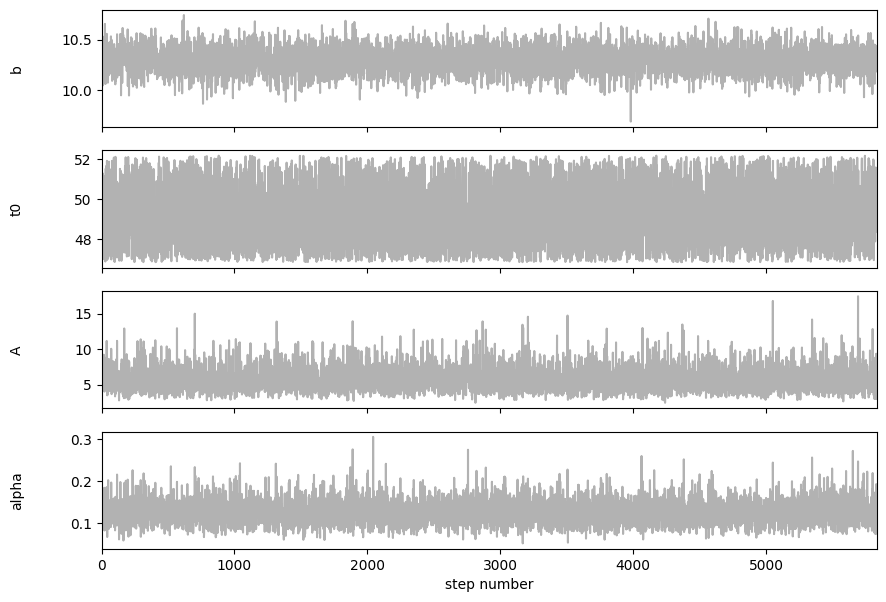

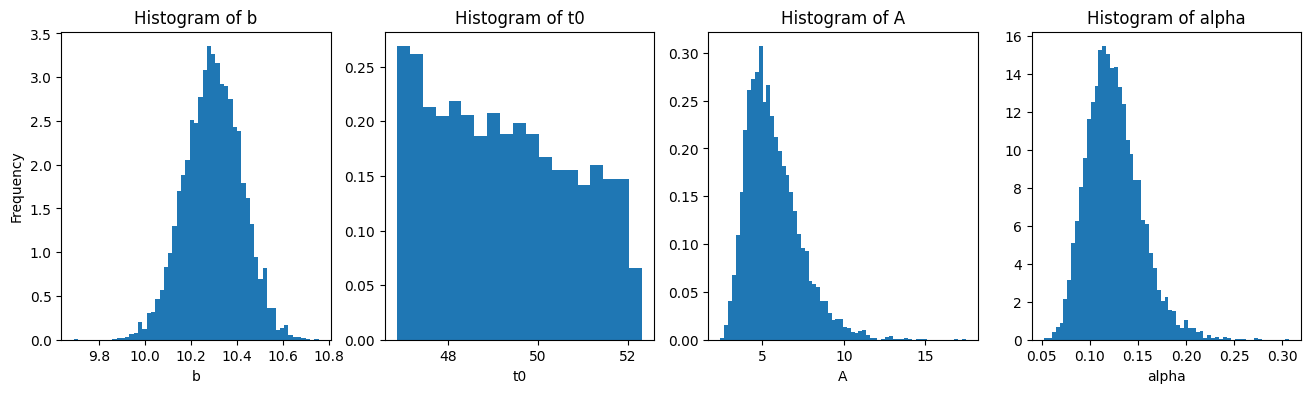

In [42]:
# get the chain
emcee_trace = sampler.get_chain(discard=burn, thin=thin, flat=True)

# plot the flattened chain
fig, axes = plt.subplots(4, figsize=(10, 7), sharex=True)
for i in range(ndim):
    ax = axes[i]
    ax.plot(emcee_trace[:, i], "k", alpha=0.3)
    ax.set_xlim(0, len(emcee_trace))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)
axes[-1].set_xlabel("step number");

# plot the histogram
fig, axes = plt.subplots(1, ndim, figsize=(4*ndim, 4))
for i in range(ndim):
    ax = axes[i]
    astropy.visualization.hist(emcee_trace[:, i], bins="freedman",density=True, ax=ax)
    #ax.hist(emcee_trace[:, i], bins=50, color='skyblue', edgecolor='k', alpha=0.7,density=True)
    ax.set_xlabel(labels[i])
    ax.set_title(f"Histogram of {labels[i]}")
axes[0].set_ylabel("Frequency")

Plot the corner plot

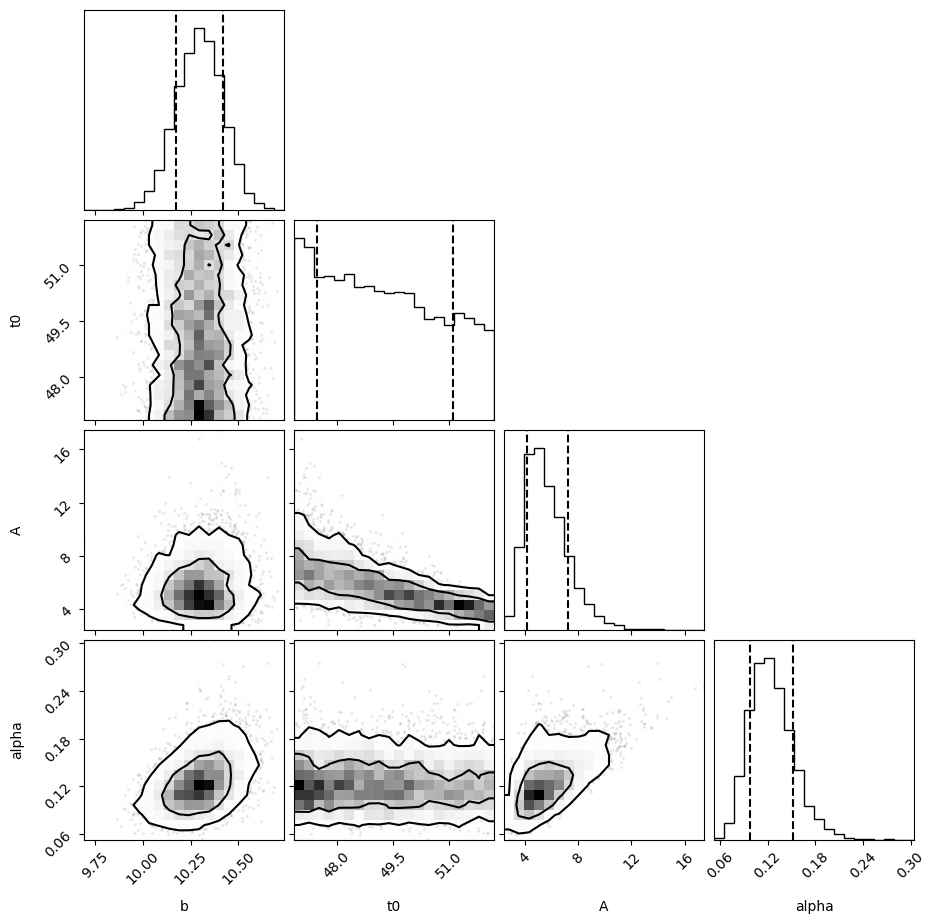

In [43]:
fig = corner.corner( emcee_trace, labels=labels,quantiles=(0.16, 0.84), levels=[0.68,0.95],titles =labels);

Compute median, interquantile ranges, credible regions and MAP values

In [44]:
# Compute statistics
medians = np.median(emcee_trace, axis=0)
q5 = np.percentile(emcee_trace, 5, axis=0)
q95 = np.percentile(emcee_trace, 95, axis=0)
ul = medians+q95
ll = medians-q5
# Print results
for i, label in enumerate(labels):
    upper = q95[i] - medians[i]
    lower = medians[i] - q5[i]
    display(Math(
        fr"\text{{Median of }} {label}: {medians[i]:.4f}, \text{{   90% credible region}}:"
        fr"{label} = {medians[i]:.4f}^{{+{upper:.4f}}}_{{-{lower:.4f}}}"
    ))
    
log_posteriors = np.array([logPosterior(params, time, flux, uncertainties) for params in emcee_trace])
map_index = np.argmax(log_posteriors)
map_params = emcee_trace[map_index]
for i, label in enumerate(labels):
    print(f"MAP value for {label}: {map_params[i]:.4f}")

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

MAP value for b: 10.2824
MAP value for t0: 49.2578
MAP value for A: 5.2389
MAP value for alpha: 0.1151


Compute the models for each posterior sample and overlap with data. The posterior spread of model solutions are consistent with the data.

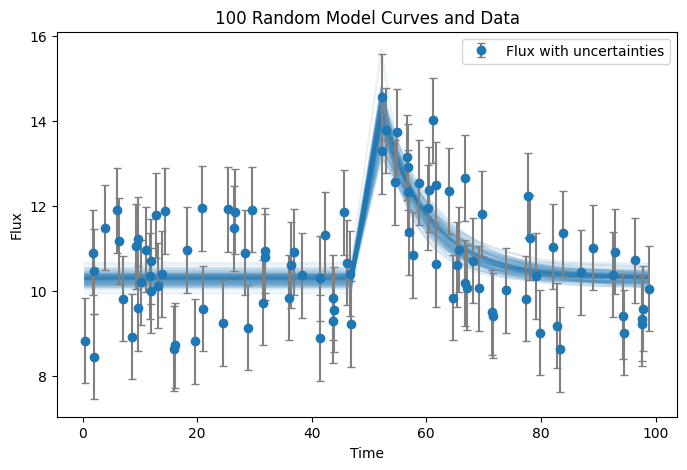

In [45]:
# show the models obtained from the posterior
models = np.array([model(params, time) for params in emcee_trace])
random_indices = np.random.choice(models.shape[0], size=100, replace=False)

plt.figure(figsize=(8, 5))

# Plot 100 random model curves with transparency
for idx in random_indices:
    plt.plot(time, models[idx, :], color='C0', alpha=0.1)

plt.errorbar(time, flux, yerr=uncertainties, fmt='o', 
             ecolor='gray', capsize=3, label='Flux with uncertainties')

plt.xlabel("Time")
plt.ylabel("Flux")
plt.title("100 Random Model Curves and Data")
plt.legend()